## Results Explorer
This notebook will take the .csv files from the data_analysis_main.py file, and plot graphs to analyse the residual and gini calculations (mean and individuals)

In [13]:
import pandas as pd
import os
import glob
import pathlib
from matplotlib import pyplot as plt
from data_analysis_main import sort_nicely
import seaborn as sns
import copy
import numpy as np

### Individual plots
1. Plot an agent's residual difference (the difference between their current residual and the previous one) on a violin graph
2. Plot an agent's residual (no difference) on a violin graph

In [14]:
# Note: anything that ends in violin is one that has individual data in it
# - individuals_difference is a residual difference compared to the previous residual
# - individuals is a residual only for a single agent
CUR_DIR = str(pathlib.Path(os.path.abspath(os.curdir)).parent) # Note, this does not include a trailing '/'
repo_root_csvs_dirs = ["/plots/SYNTH_vary_grp_fact_500_runs/", "/plots/SYNTH_vary_mup_vamu_500_runs/", "/plots/SYNTH_vary_pvs_prip_500_runs/"]
values_list = "pvs" # The values used in each residual calculation will be at the front of the file
# Find all .csvs and sort so order will be the same
ind_files, ind_diff_files, gini_files = [], [], []
for repo_root_csvs_dir in repo_root_csvs_dirs:
    ind_file = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_residuals_individuals[!_]*")
    ind_diff_file = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_residuals_individuals_difference*")
    gini_file = glob.glob(CUR_DIR+repo_root_csvs_dir+values_list+"_ginigini.csv")
    ind_file, ind_diff_file, gini_file = sort_nicely(ind_file), sort_nicely(ind_diff_file), sort_nicely(gini_file)[0]
    ind_files.append(ind_file), ind_diff_files.append(ind_diff_file), gini_files.append(gini_file)

# import each csv into a dataframe and store in a dict = {baseline key: df, ...}
experiment_dicts = {}
for gini_count, (ind_file_list, ind_diff_file_list) in enumerate(zip(ind_files, ind_diff_files)):
    ind_dfs, ind_diff_dfs, gini_dfs = {}, {}, {}
    gini_df = pd.read_csv(gini_files[gini_count], header=None, skiprows=1)
    gini_df = gini_df.T
    gini_df.columns = gini_df.iloc[0]
    gini_df.drop(gini_df.index[0], inplace=True)
    for ind_file, ind_diff_file in zip(ind_file_list, ind_diff_file_list):
        # Load in the gini file for this
        baseline_name = ind_file.split("/")[-1].split("_")[2] # Because we sorted, ind_file and ind_diff_files will be equal
        baseline_name = baseline_name[11:-10]
        # Read CSV without treating first row as header
        ind_dfs[baseline_name] = pd.read_csv(ind_file, header=None, skiprows=1)
        ind_diff_dfs[baseline_name] = pd.read_csv(ind_diff_file, header=None, skiprows=1)
        # Assign column names (0, 1, 2, ...)
        ind_dfs[baseline_name].columns = range(len(ind_dfs[baseline_name].columns))
        ind_diff_dfs[baseline_name].columns = range(len(ind_diff_dfs[baseline_name].columns))
        # Remove the agent_id and the initial points (for ind_diff_dfs)
        ind_dfs[baseline_name].drop(0, axis=1, inplace=True)
        ind_diff_dfs[baseline_name].drop([0,1], axis=1, inplace=True)
    experiment_name = ind_file_list[0].split("/")[-2]
    experiment_dicts[experiment_name] = [copy.deepcopy(ind_dfs), copy.deepcopy(ind_diff_dfs), copy.deepcopy(gini_df)]

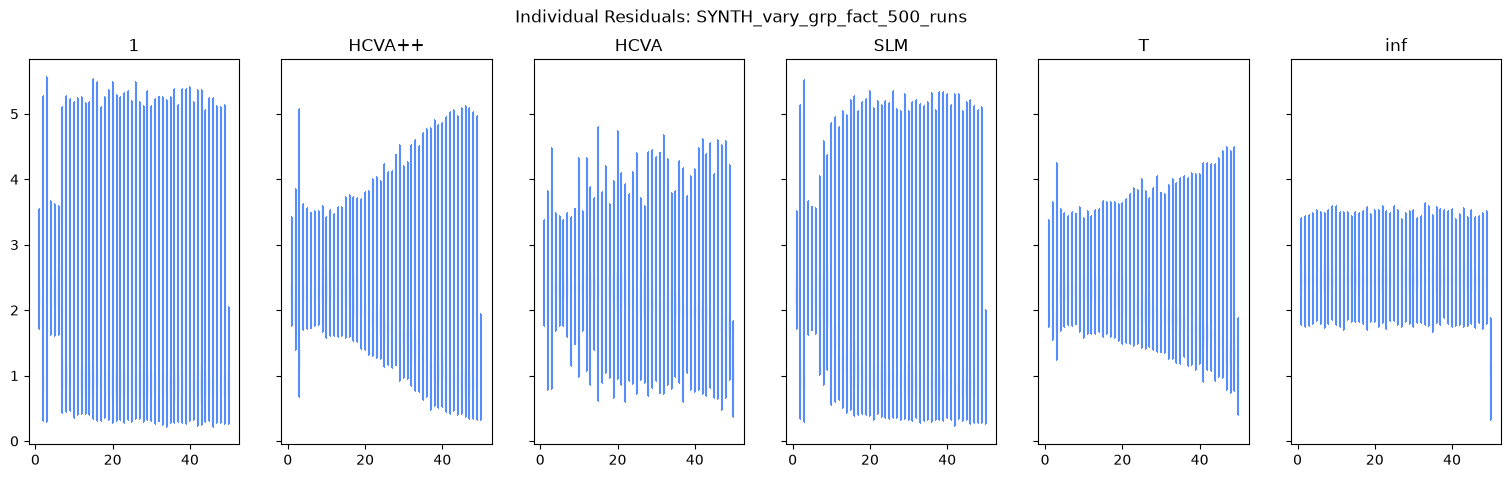

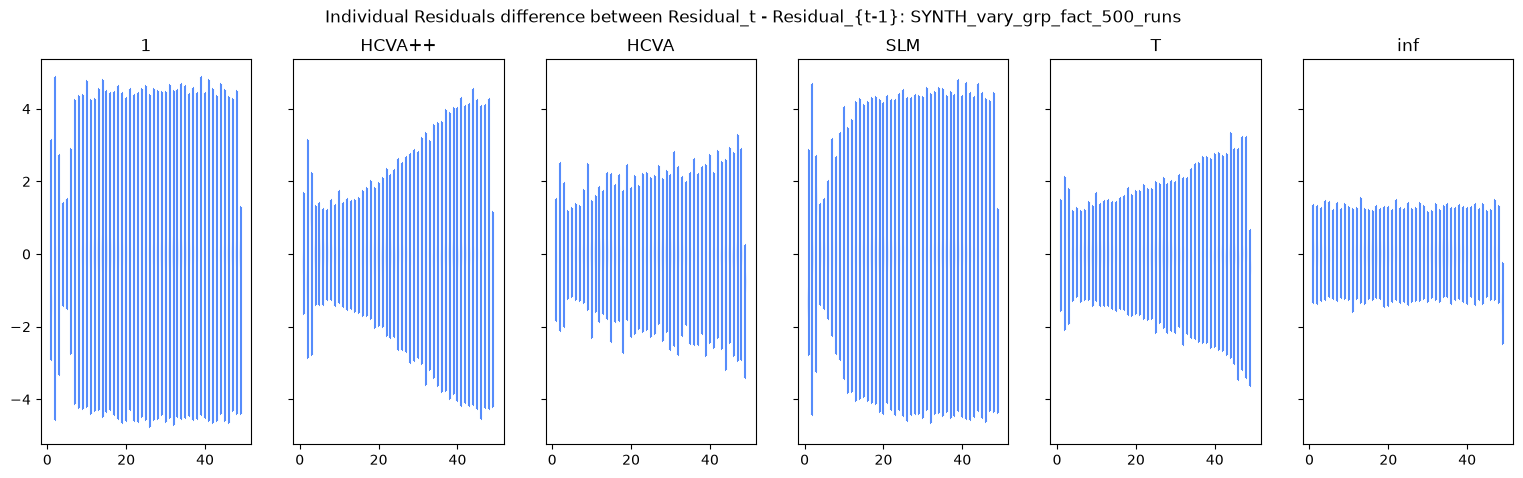

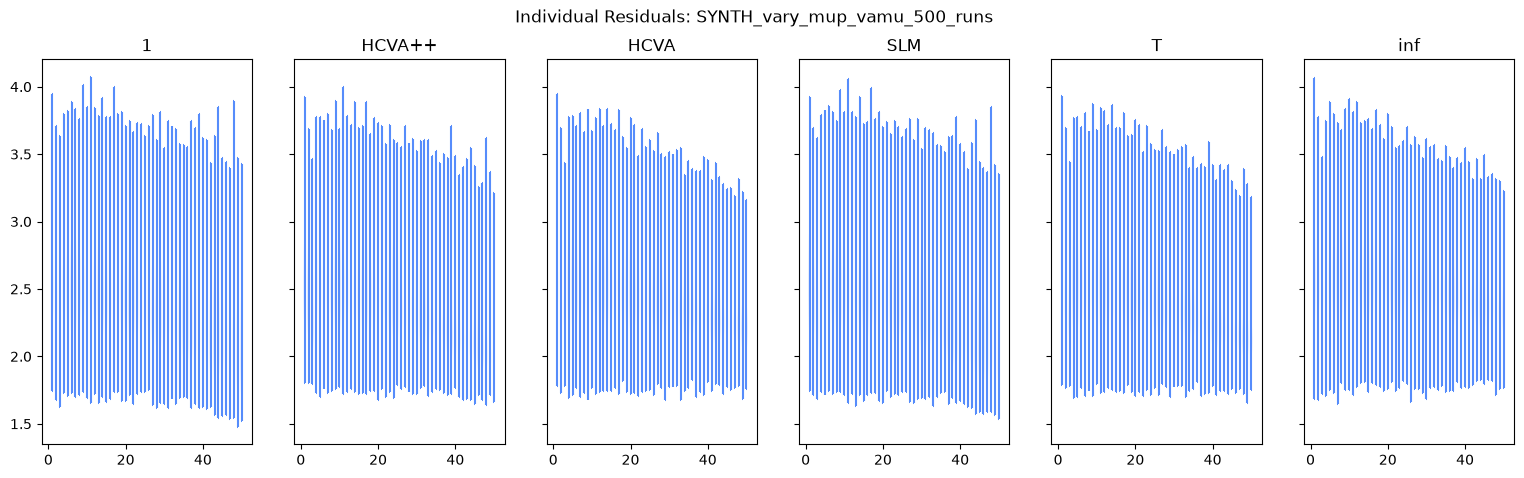

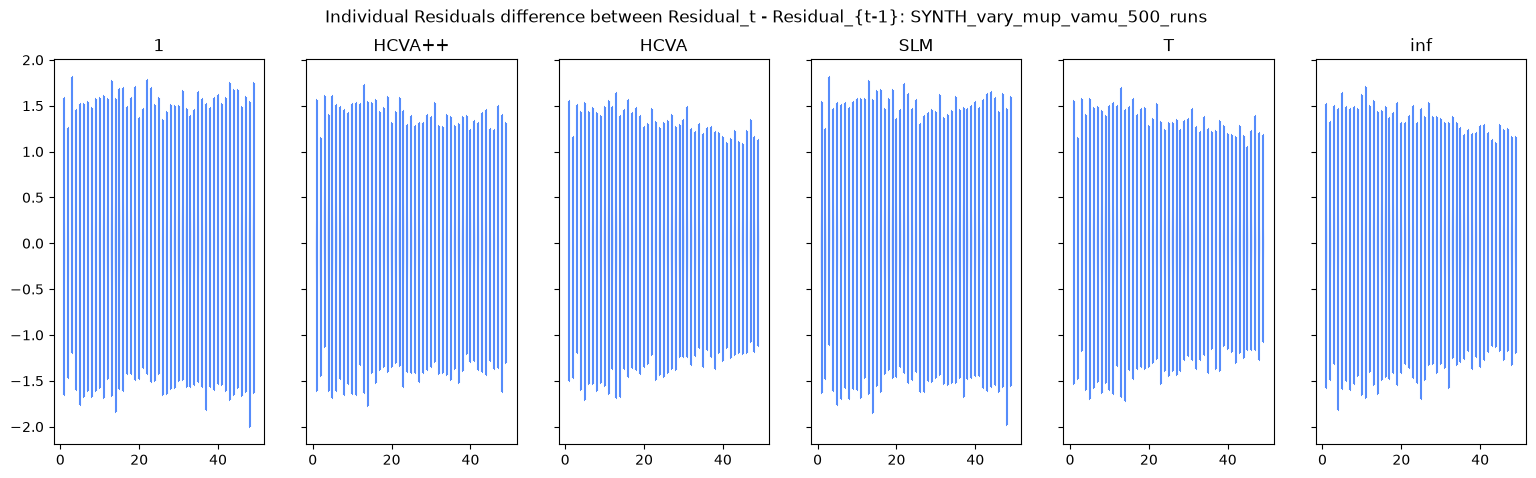

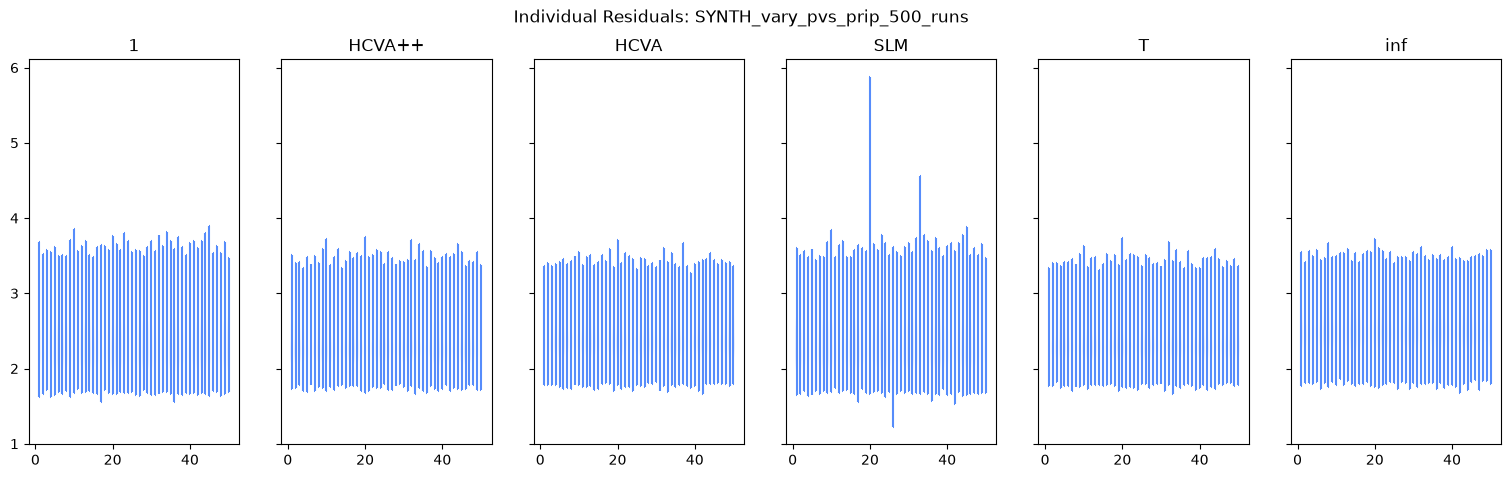

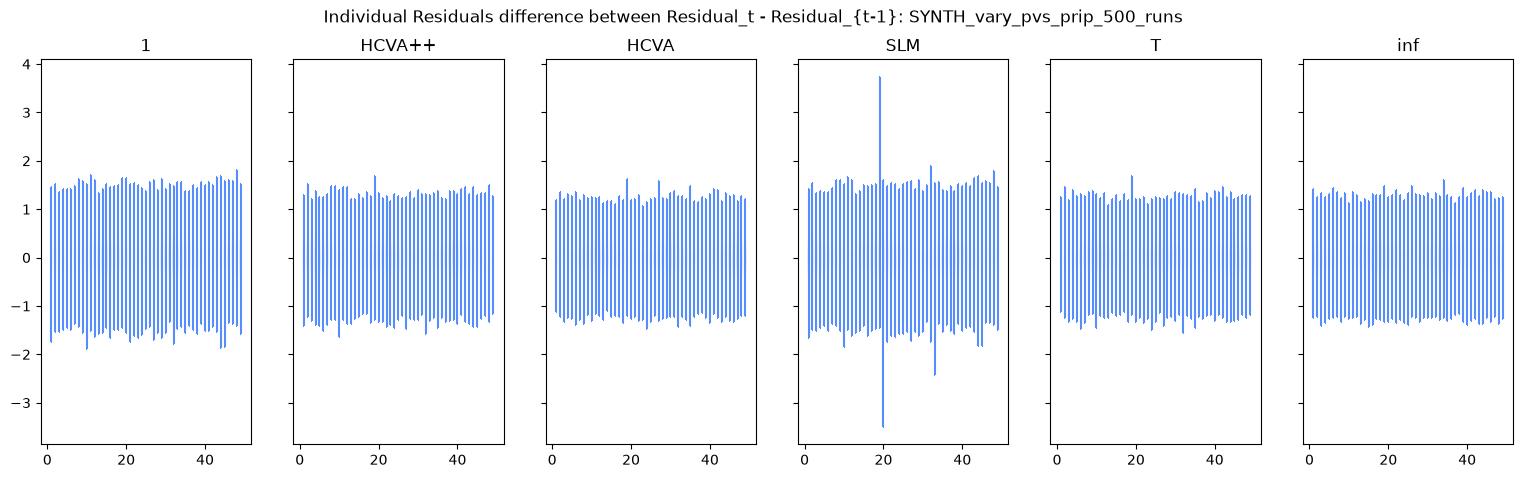

In [15]:
for exp_name, [ind_dfs, ind_diff_dfs, _] in experiment_dicts.items():
    # Plot each row (where col[0] for each df is an ID) onto a violin plot. Overlay for each method and plot as a 3x2 grid
    fig_ind, axes_ind = plt.subplots(1, 6,  sharex=True, sharey=True, figsize=(19,5))
    fig_ind.suptitle("Individual Residuals: "+exp_name)
    fig_ind_diff, axes_ind_dff = plt.subplots(1, 6,  sharex=True, sharey=True, figsize=(19,5))
    fig_ind_diff.suptitle("Individual Residuals difference between Residual_t - Residual_{t-1}: "+exp_name)
    for ax_ind, ax_ind_diff, key in zip(axes_ind.flatten(), axes_ind_dff.flatten(), ind_dfs.keys()):
        ax_ind.set_title(key)
        ax_ind_diff.set_title(key)
        ax_ind.violinplot(ind_dfs[key].values, showmeans=False, showmedians=False, showextrema=True)
        ax_ind_diff.violinplot(ind_diff_dfs[key].values, showmeans=False, showmedians=False, showextrema=True)
plt.show() # This plot shows a violin plot per time step (x), showing the individual agent data that has been averaged over 500 runs.

### Quartile Plots
3. Plot residual and residual differences as an upper or lower quartile of all agents. That means we can represent those who are always given poor residuals vs those that are given the best (even if the agent IDs input data characteristics are different at each time). 

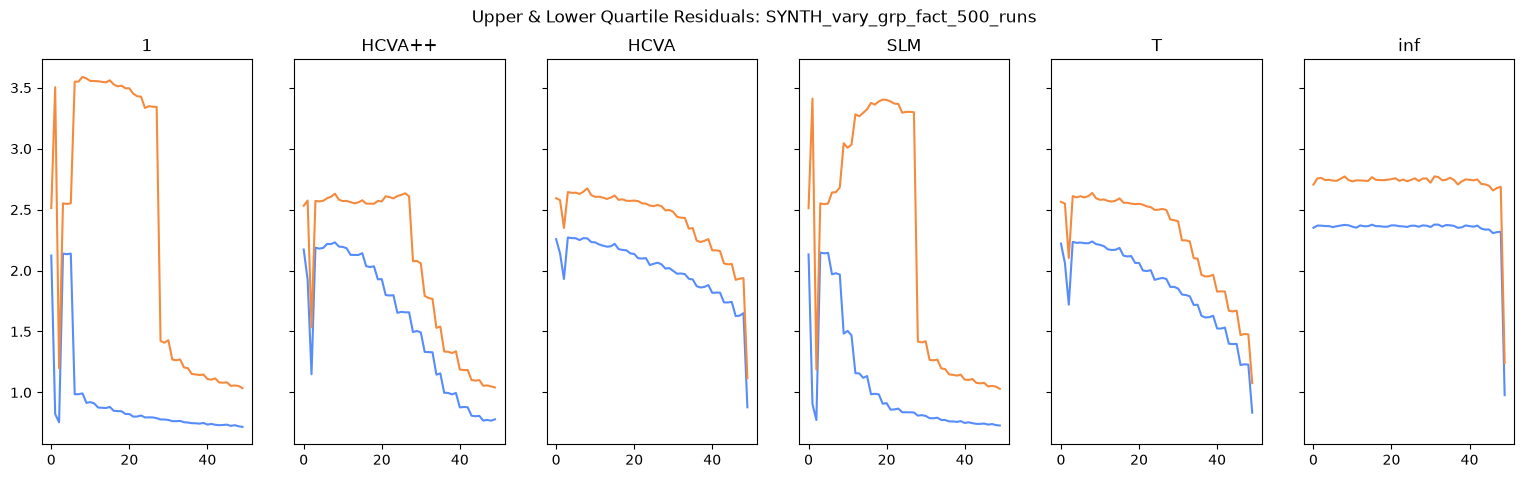

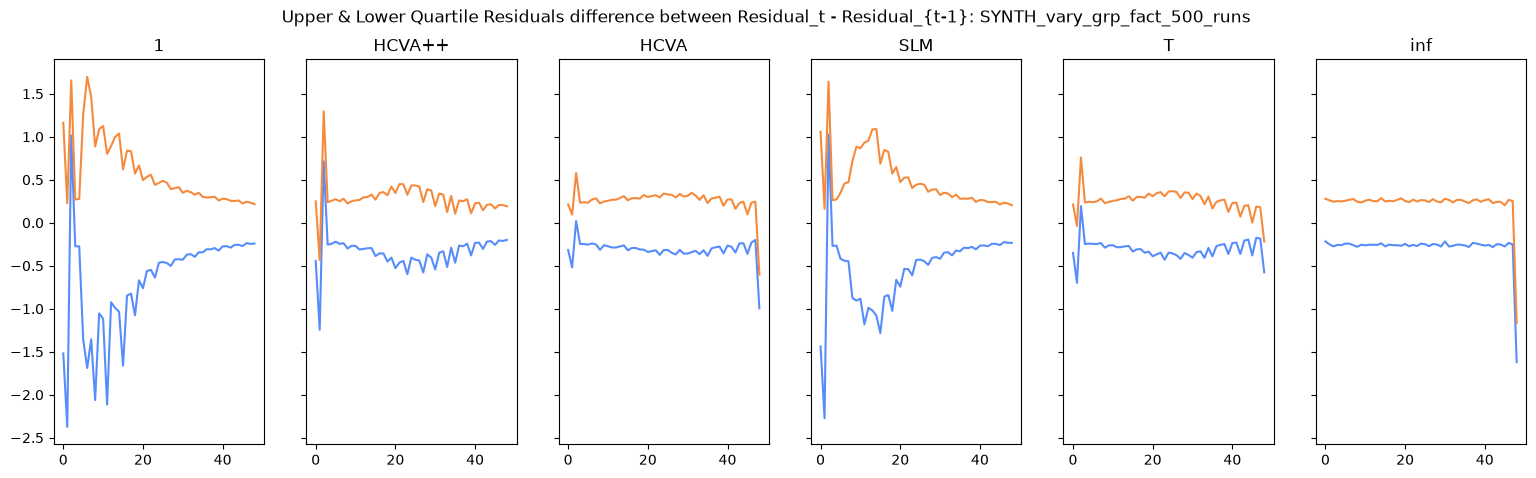

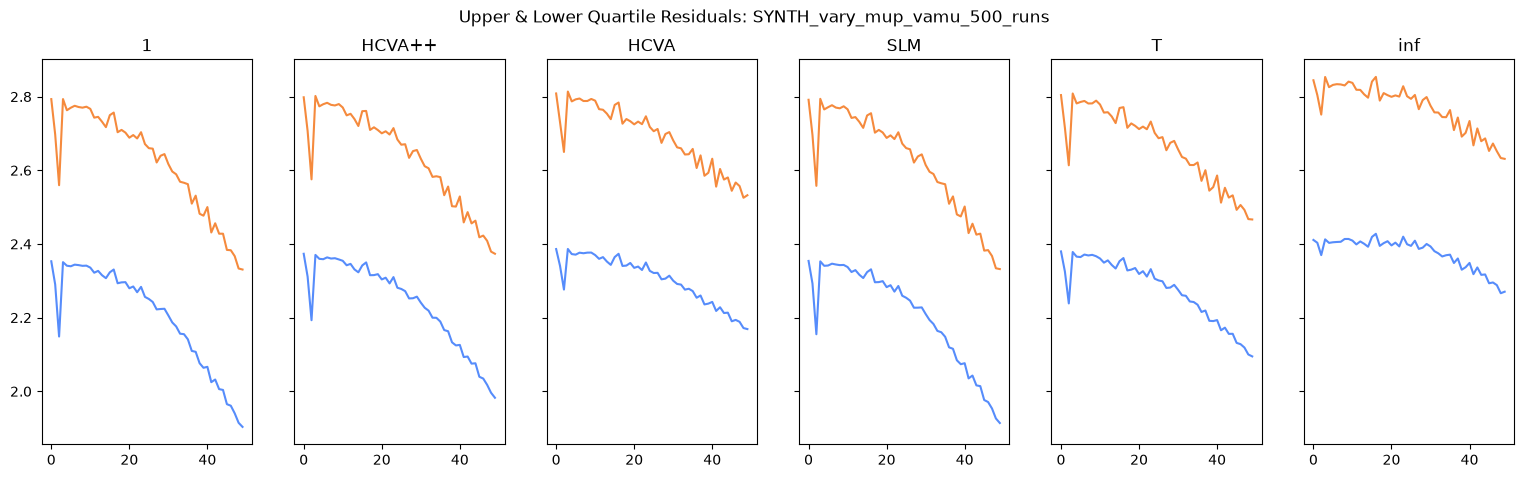

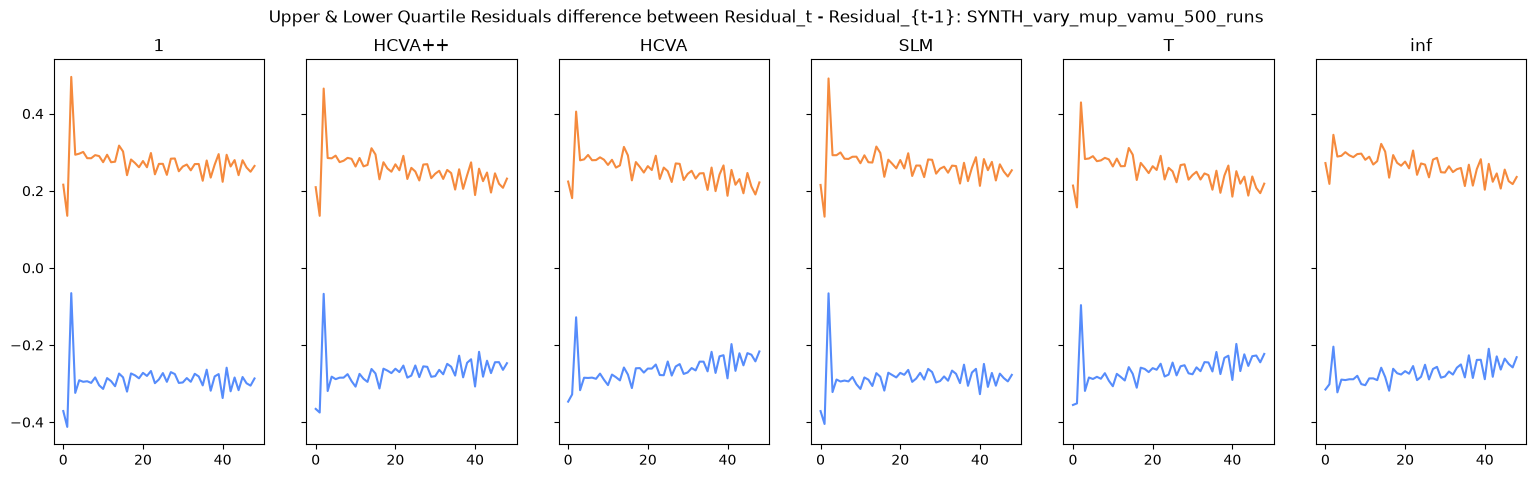

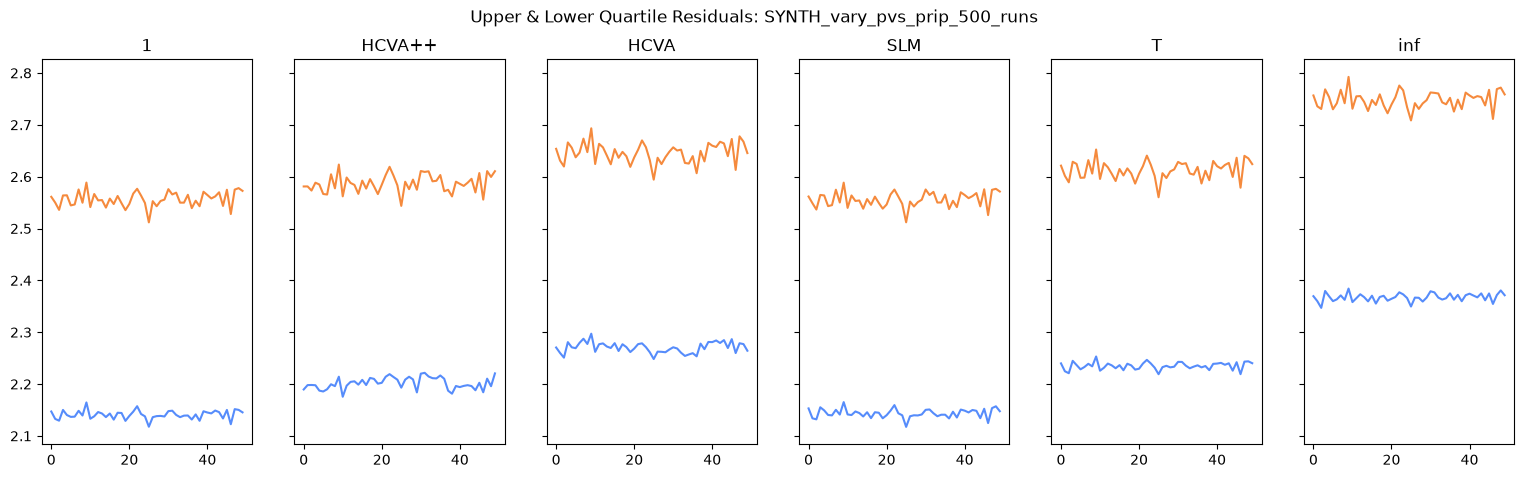

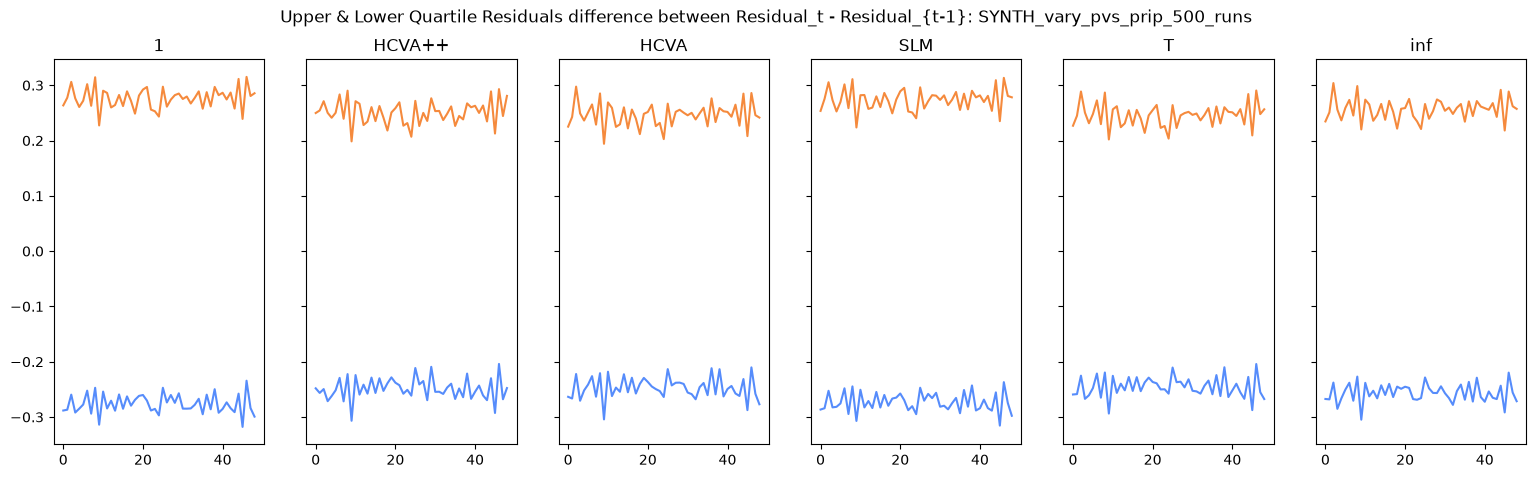

In [37]:
for exp_name, [ind_dfs, ind_diff_dfs, _] in experiment_dicts.items():
    # Refactor ind_dfs/ind_diff_dfs by finding the upper and lower quartiles for each timestep in their dataframes, and only keeping those. Returning ind_dfs = {key: dataframe with 2 rows)
    ind_quantile_dfs = {}
    ind_diff_quantile_dfs = {}
    for (key, ind_df), (key, ind_diff_df) in zip(ind_dfs.items(), ind_diff_dfs.items()):
        ind_quantile_dfs[key] = ind_df.quantile(q=[0.25, 0.75], axis=0)
        ind_diff_quantile_dfs[key] = ind_diff_df.quantile(q=[0.25, 0.75], axis=0)

    # Plot each row (where col[0] for each df is an ID) onto a violin plot. Overlay for each method and plot as a 3x2 grid
    fig_ind, axes_ind = plt.subplots(1, 6,  sharex=True, sharey=True, figsize=(19,5))
    fig_ind.suptitle("Upper & Lower Quartile Residuals: "+exp_name)
    fig_ind_diff, axes_ind_dff = plt.subplots(1, 6,  sharex=True, sharey=True, figsize=(19,5))
    fig_ind_diff.suptitle("Upper & Lower Quartile Residuals difference between Residual_t - Residual_{t-1}: "+exp_name)
    for ax_ind, ax_ind_diff, key in zip(axes_ind.flatten(), axes_ind_dff.flatten(), ind_quantile_dfs.keys()):
        ax_ind.set_title(key)
        ax_ind_diff.set_title(key)
        # Upper Quartile
        ax_ind.plot(ind_quantile_dfs[key].iloc[[0]].values[0])
        ax_ind_diff.plot(ind_diff_quantile_dfs[key].iloc[[0]].values[0])
        ax_ind.plot(ind_quantile_dfs[key].iloc[[1]].values[0])
        ax_ind_diff.plot(ind_diff_quantile_dfs[key].iloc[[1]].values[0])
plt.show() # This plot shows a violin plot per time step (x), showing the individual agent data that has been averaged over 500 runs.

### Violin plots - Small
4 . Rather than plotting a violin per single timestep, plot a violin for 3 key timesteps. E.g. For grp-fact, plot a violin for t=0, t=25, t=50 to see 50/50, 25/75, 0/100

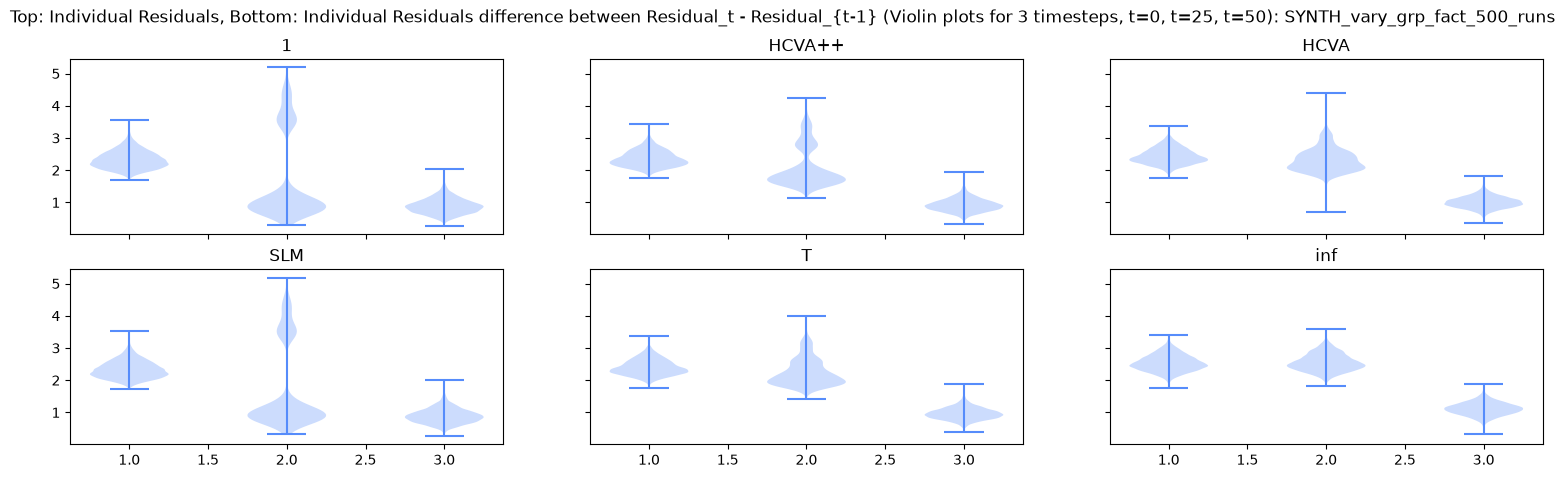

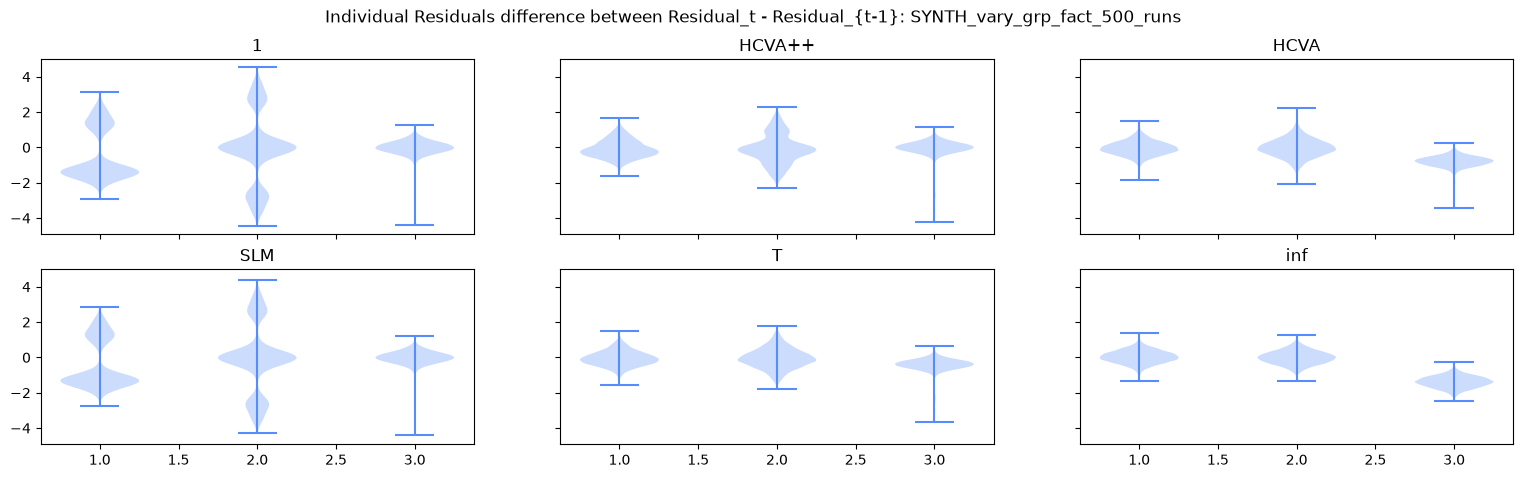

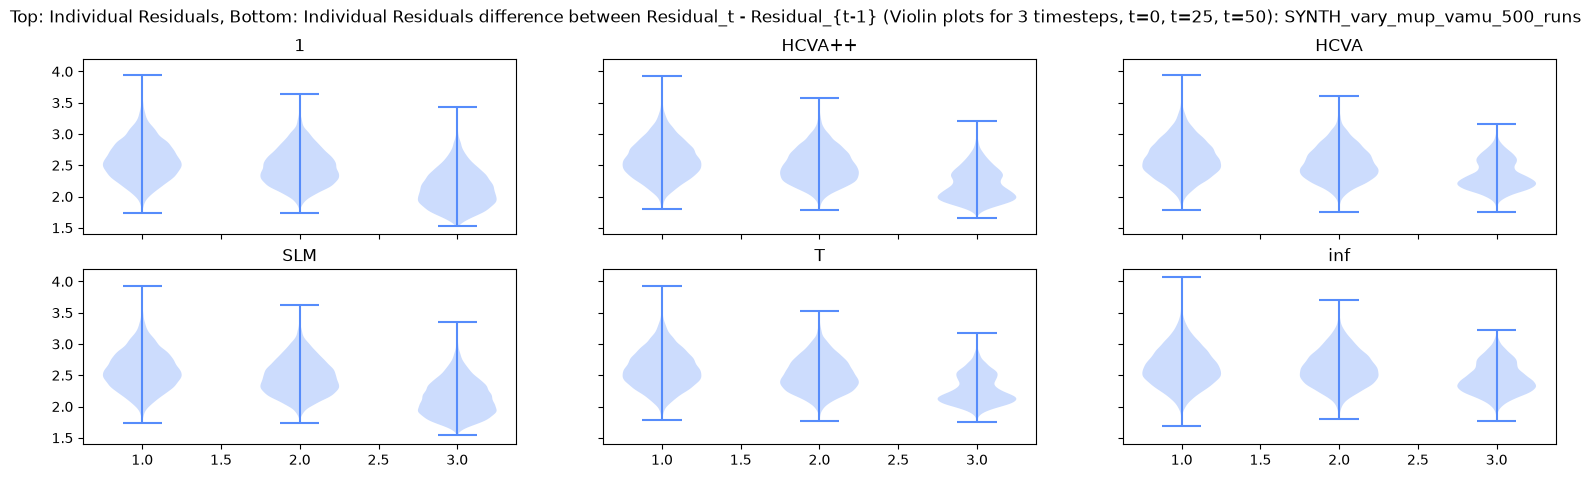

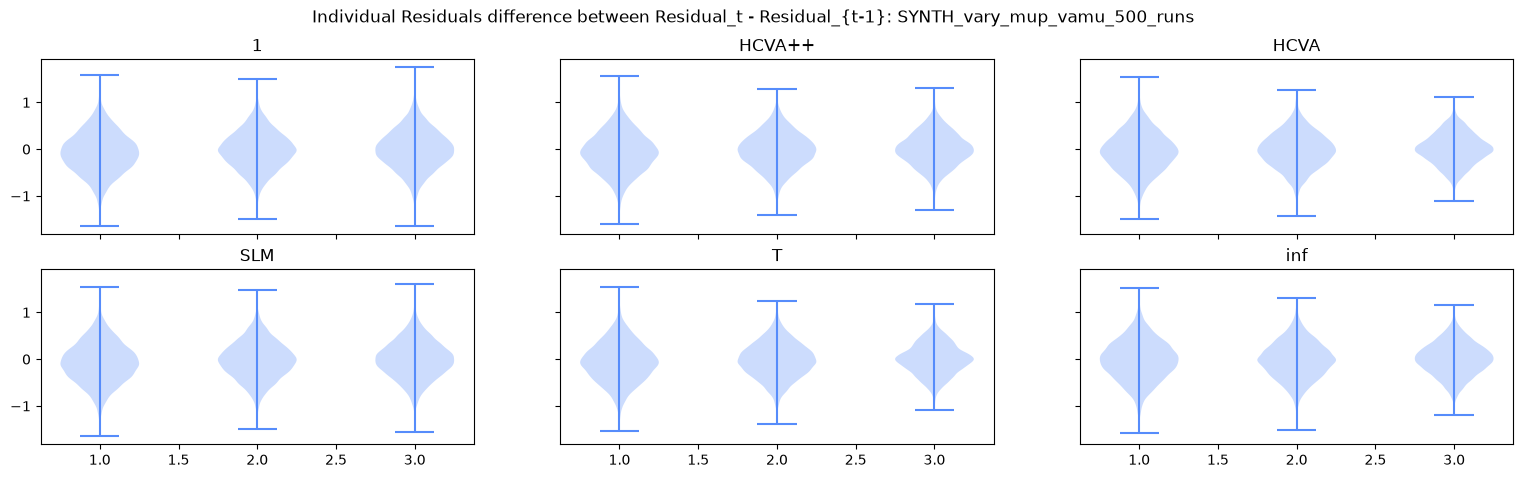

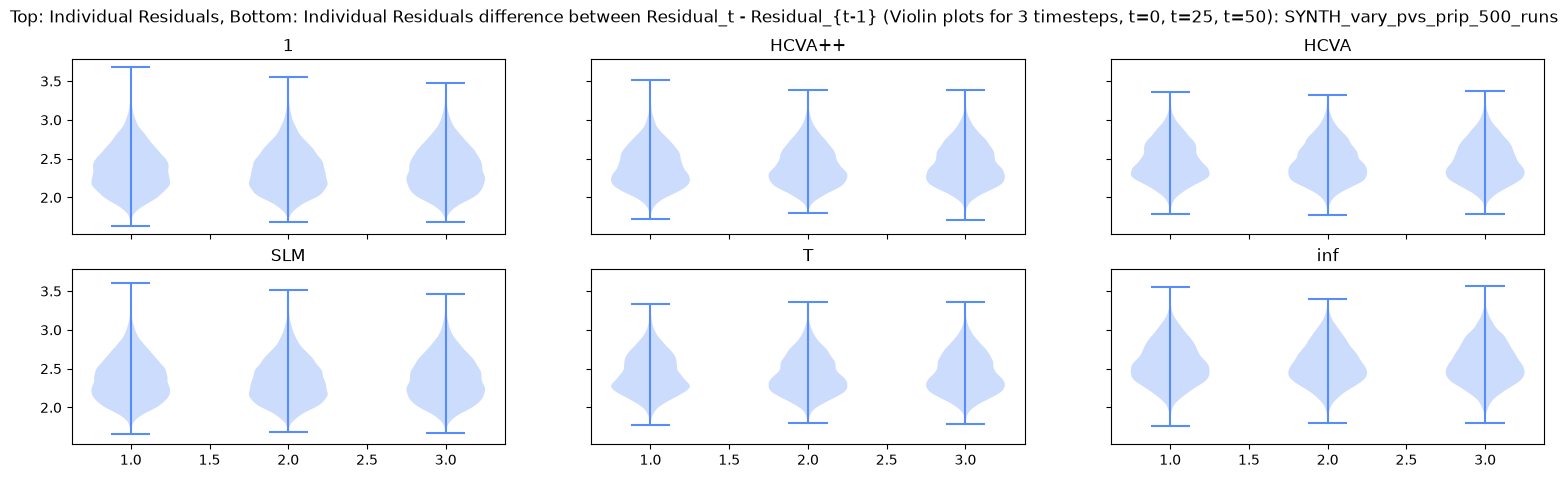

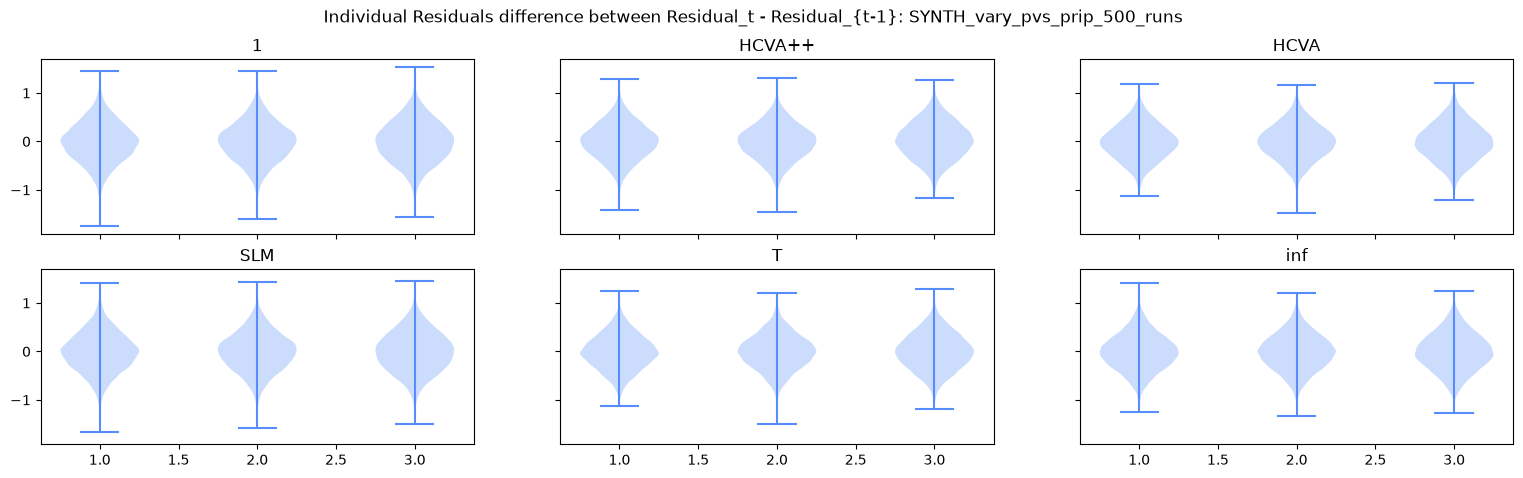

In [17]:
for exp_name, [ind_dfs, ind_diff_dfs, _] in experiment_dicts.items():
    # Plot each row (where col[0] for each df is an ID) onto a violin plot. Overlay for each method and plot as a 3x2 grid
    fig_ind, axes_ind = plt.subplots(2, 3,  sharex=True, sharey=True, figsize=(19,5))
    fig_ind.suptitle("Top: Individual Residuals, Bottom: Individual Residuals difference between Residual_t - Residual_{t-1} (Violin plots for 3 timesteps, t=0, t=25, t=50): "+exp_name)
    fig_ind_diff, axes_ind_dff = plt.subplots(2, 3,  sharex=True, sharey=True, figsize=(19,5))
    fig_ind_diff.suptitle("Individual Residuals difference between Residual_t - Residual_{t-1}: "+exp_name)
    for ax_ind, ax_ind_diff, key in zip(axes_ind.flatten(), axes_ind_dff.flatten(), ind_dfs.keys()):
        # Cut
        ind_cut = ind_dfs[key][[1, 25, 50]]
        ind_diff_cut = ind_diff_dfs[key][[2, 25, 50]]
        ax_ind.set_title(key)
        ax_ind_diff.set_title(key)
        ax_ind.violinplot(ind_cut.values, showmeans=False, showmedians=False, showextrema=True)
        ax_ind_diff.violinplot(ind_diff_cut.values, showmeans=False, showmedians=False, showextrema=True)
    plt.show() # This plot shows a violin plot per time step (x), showing the individual agent data that has been averaged over 500 runs.

### Group A or B?
5. Plot different colours for whether an agent is in group A or group B for the grp_fact experiment
6. Plot different colours for whether an agent's values are mostly neutral, or whether they are more extreme for mup_vamu experiment
7. Plot different colours for whether an agent's


### Mean residuals
8. Plot a line graph showing the mean residual for a method at a particular timestep, where x = timestep (the varying parameter for the experiment). Add a translucent space for standard deviation for each run

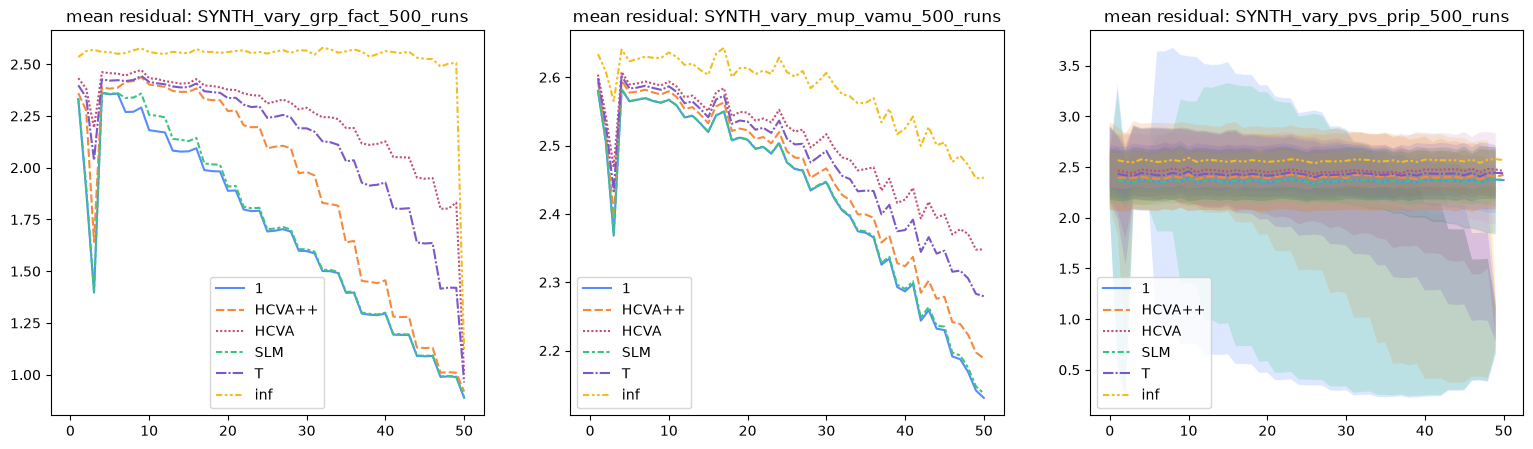

In [18]:
fig, axes = plt.subplots(1, 3,  sharex=True, sharey=False, figsize=(19,5))
#fig.suptitle("Top: Individual Residuals, Bottom: Individual Residuals difference between Residual_t - Residual_{t-1} (Violin plots for 3 timesteps, t=0, t=25, t=50): "+exp_name)
for (exp_name, [ind_dfs, ind_diff_dfs, _]), ax in zip(experiment_dicts.items(), axes.flatten()):
    # Make a new dataframe where each col is a method, and each row is a mean (following seaborn)
    plot_df = pd.DataFrame()
    std_df = pd.DataFrame()
    for key, df in ind_dfs.items():
        plot_df[key] = df.mean(axis=0)
        std_df[key] = df.std(axis=0)
        plt.fill_between(np.arange(0,50,1), np.subtract(plot_df[key], std_df[key]), np.add(plot_df[key], std_df[key]), alpha=0.2)
    sns.lineplot(data=plot_df,ax=ax).set(title="mean residual: "+exp_name)
plt.show()

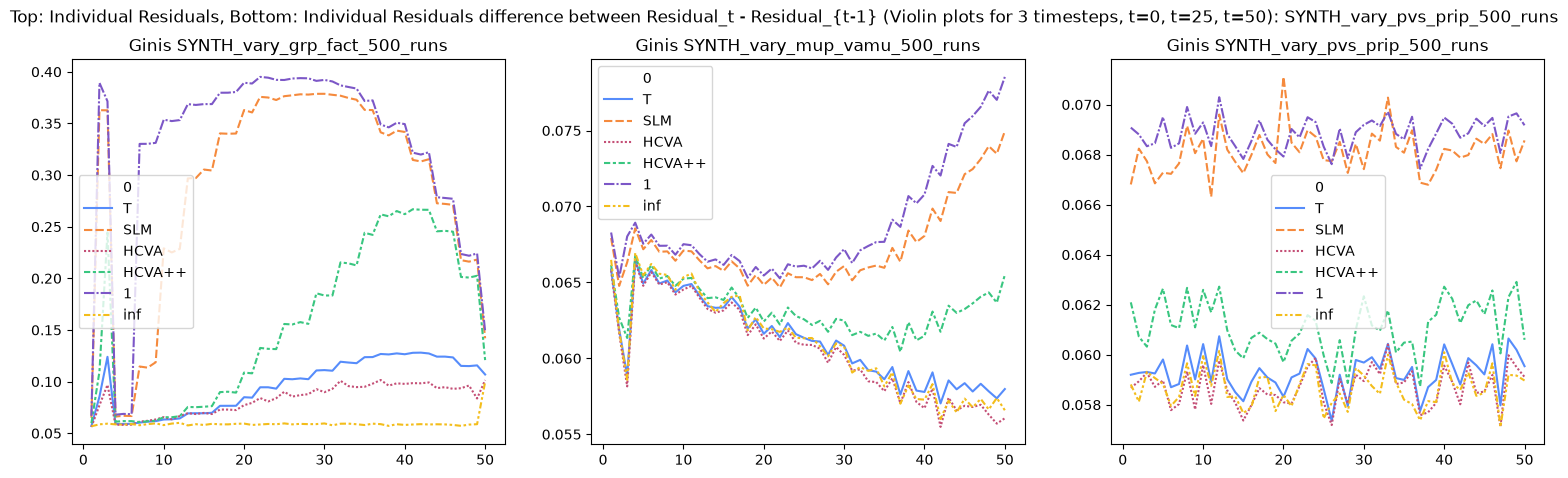

In [19]:
fig, axes = plt.subplots(1, 3,  sharex=True, sharey=False, figsize=(19,5))
fig.suptitle("Gini index as paramter varies "+exp_name)
for (exp_name, [_, _, gini_df]), ax in zip(experiment_dicts.items(), axes.flatten()):
    sns.lineplot(data=gini_df, ax=ax).set(title="Ginis "+exp_name)


### Fairness vs Utility Scatter
9. Plot the Gini vs mean residual per method per parameter value as a scatter graph. Each method should trace the curve between fairness/utility space as the parameter varies. Conclusions: whether methods that lower residuals do so by sacraficing minority agents

### Other ideas:

10.Polarisation sensitivity (vary_mup_vamu)
At high mu_p/va_mu (extreme preferences), do methods converge on different consensus_preference values (egalitarian vs. utilitarian)? Plot consensus_preference per method vs. the parameter  SLM and HCVA++ likely differ from L1/Linf here.

11. Noise robustness threshhold
For pvs_prip, plot residual variance (not just mean) per method vs. noise level. Find where variance spikes. this is the noise tolerance threshold. Methods like SLM that use PriP should degrade earlier than those that don't.

12. Method rankings are stable/flip points
Compute rank order of methods by residual at each parameter step, then plot rank as a line per method. Crossing lines reveal conditions where one method overtakes another. these are the most interesting points to inspect qualitatively.
